# **STAGE 3 - EDA AND VISUALISATION**

## **Objectives**

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## **Inputs**

* The data input I need for this section is the cleaned dataset I created in **Stage 2 - ETL**: `datasets/cleaned-data/bank-churners-cleaned.csv`

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 


---

## **Change Working Directory**

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/credit-card-customer-churn-analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/credit-card-customer-churn-analysis'

---

## **Import Libraries and Packages**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from scipy import stats
sns.set_style("whitegrid")
sns.set_palette("PiYG", n_colors=6)
colours = sns.color_palette("PiYG", n_colors=2)

---

## **Load the Dataset**

In [5]:
# Load the cleaned dataset
df_vis = pd.read_csv("datasets/cleaned-data/bank-churners-cleaned.csv")

# Display the first few rows of the dataset to make sure the data has loaded correctly
df_vis.head()

,anonymised_clientnum,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Attrition_Flag_Binary
0,022e52f0a251431f954db620fd0c87ac3c523c60cc5980...,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,3,12691.0,777.0,11914.0,1.335,1144.0,42,1.625,0.061,0
1,2731de4ed9ecb2a3ab828448bfda6137e5c7571e1f7576...,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,2,8256.0,864.0,7392.0,1.541,1291.0,33,3.714,0.105,0
2,75dac624c2bbdb15b16abc0350820bcf598c012a76b102...,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,0,3418.0,0.0,3418.0,2.594,1887.0,20,2.333,0.000,0
3,1aaada0cd1f7dc23d83a171beec9f398cfac1471841843...,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,1,3313.0,2517.0,796.0,1.405,1171.0,20,2.333,0.760,0
4,1811f55b3210153f77e41ceceb61cc181d2edc4e65947e...,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,0,4716.0,0.0,4716.0,2.175,816.0,28,2.500,0.000,0


---

## **1. Exploratory Data Analysis (EDA)**

### **1.1 Attrition Flag - Analysis of Target Variable**

Seeing as `Attrition_Flag` (or at least, `Attrition_Flag_Binary`) is going to be the target variable in **Stage 4 - Machine Learning**, it will be good to get a sense of the split between existing and attrited customers.

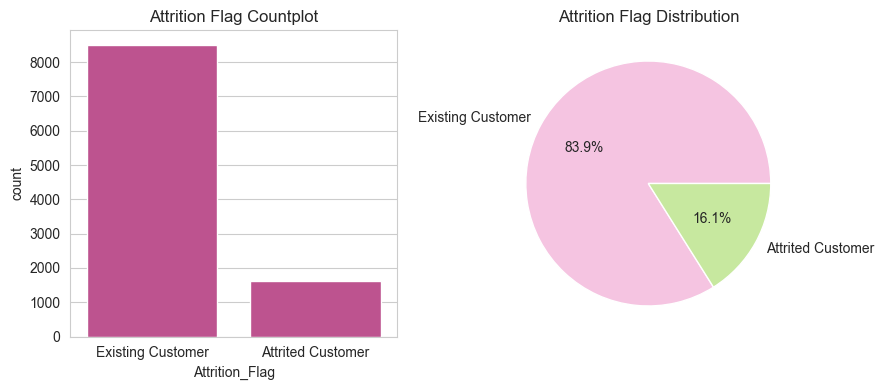

In [7]:
# Map a countplot and pie chart for attrition flag variable
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), tight_layout=True)

sns.countplot(data=df_vis, x="Attrition_Flag", ax=axes[0])
axes[0].set_title("Attrition Flag Countplot")

axes[1].pie(
    df_vis["Attrition_Flag"].value_counts(),
    labels=df_vis["Attrition_Flag"].value_counts().index, 
    colors = colours, autopct="%1.1f%%")
axes[1].set_title("Attrition Flag Distribution")

plt.show()

Given what we can see here, the `Attrition_Flag` values are imbalanced. This is very important to note because it affects how we will need to look at machine learning - accuracy alone will not be a good judge of the performance of a machine learning model. 